# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스

## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스
* 학습의 모든 과정을 커스텀화 할 수 있음

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [7]:
data['Family'] = data['SibSp'] + data['Parch'] # Family에 합쳐주기
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,Family
0,0,3,male,22.0,1,0,S,1
1,1,1,female,38.0,1,0,C,1
2,1,3,female,26.0,0,0,S,0
3,1,1,female,35.0,1,0,S,1
4,0,3,male,35.0,0,0,S,0


In [8]:
data = data.drop(['SibSp', 'Parch'], axis=1) # 기존 데이터 삭제
data.head()

,Survived,Pclass,Sex,Age,Embarked,Family
0,0,3,male,22.0,S,1
1,1,1,female,38.0,C,1
2,1,3,female,26.0,S,0
3,1,1,female,35.0,S,1
4,0,3,male,35.0,S,0


In [9]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [10]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [13]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 748 to 136
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    623 non-null    int64  
 1   Sex       623 non-null    str    
 2   Age       504 non-null    float64
 3   Embarked  621 non-null    str    
 4   Family    623 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 29.2 KB


# 딥러닝시에도 데이터 스케일을 맞춰 주어야 함
* MinMaxScaler를 주로 사용, StandardScaler도 사용, 이상값이 많은 경우 RobustScaler 사용
* 이진분류: MixMax
* 연속값예측: Standard

* 숫자 = MinMax
* 문자열 = OneHotencoder

In [14]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'Family'], dtype='str')

In [15]:
num_cols = ['Age', 'Family'] # 숫자 int 분류
cat_cols = ['Pclass', 'Sex', 'Embarked'] # 문자열 str 분류

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [20]:
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('mmx', MinMaxScaler())  
])

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

prep = ColumnTransformer(transformers=[
    ('num_cols', num_pipe, num_cols),
    ('cat_cols', cat_pipe, cat_cols)
], remainder='drop')

X_train_ppd = prep.fit_transform(X_train)
X_test_ppd = prep.transform(X_test)

# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석

* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층, 레이어, 입력층, 은닉층, 출력층

In [23]:
import keras
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Dense

* 입력층은 반드시 독립변수의수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Relu
* 출력층은 이진분류일 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 출력층에 활성화 함수 없이 노드를 1로 지정

In [26]:
# 독립변수 수 계산 shape[1]
X_train.shape[1]

5

In [42]:
# # 옛날 버전 코드
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# model = Sequential()

# model.add(Dense(64,
#                 activation='relu',
#                 input_dim=X_train_ppd.shape[1]))  # 입력층

# model.add(Dense(32, activation='relu'))  # 은닉층
# model.add(Dense(16, activation='relu'))  # 은닉층

# model.add(Dense(1, activation='sigmoid'))  # 출력층

In [43]:
# keras 3.0 기준 신경망 모델 정의
model = Sequential()
model.add(Input(shape=(X_train_ppd.shape[1],))) # 입력층
model.add(Dense(64, activation='relu')) # 은닉층
model.add(Dense(32, activation='relu')) # 은닉층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(1, activation='sigmoid'))# 출력층, 이전분류이므로 sigmoid

In [44]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

#  모델의 파라미터 세팅 model.compile()
* loss: 오차 계산 지표
  * 이진분류: binary_crossentropy
  * 다중분류: categorical_crossentropy - y가 one-hot encoding
  * 다중분류2: sparse_categorical_crossentropy - y가 label encoding
  * 연속형데이터(회귀분석): mse
* optimizer: learning_rate
  * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [45]:
y_train # sparse_categorical_crossentropy을 써야함

748    0
45     0
28     1
633    0
403    0
      ..
476    0
190    1
736    0
462    0
136    1
Name: Survived, Length: 623, dtype: int64

In [46]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 훈련 model.fit(X_train, y_train)
* epochs: 전체 데이터를 한 번 훈련하는 주기, 10-100 사이
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절(2의 배수) 32, 64로 쪼개서 넣는 것 추천
* validation_data: 검증 데이터로 모델 검증 실시

In [47]:
history = model.fit(X_train_ppd, y_train, epochs=300, batch_size=16, 
                    validation_data=(X_test_ppd, y_test))

Epoch 1/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6485 - loss: 0.6627 - val_accuracy: 0.7985 - val_loss: 0.6048
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7657 - loss: 0.5639 - val_accuracy: 0.7799 - val_loss: 0.5171
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7849 - loss: 0.4958 - val_accuracy: 0.8134 - val_loss: 0.4798
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7913 - loss: 0.4657 - val_accuracy: 0.8172 - val_loss: 0.4523
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8074 - loss: 0.4517 - val_accuracy: 0.8172 - val_loss: 0.4417
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7978 - loss: 0.4442 - val_accuracy: 0.7761 - val_loss: 0.4470
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8058 - loss: 0.4370 - val_accuracy: 0.8172 - val_loss: 0.4301
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8138 - loss: 0.4327 - val_accuracy: 0.8134 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8427 - loss: 0.3837 - val_accuracy: 0.8209 - val_loss: 0.4179
Epoch 52/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8363 - loss: 0.3868 - val_accuracy: 0.8134 - val_loss: 0.4144
Epoch 53/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8347 - loss: 0.3861 - val_accuracy: 0.7836 - val_loss: 0.4164
Epoch 54/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8427 - loss: 0.3825 - val_accuracy: 0.8209 - val_loss: 0.4159
Epoch 55/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8459 - loss: 0.3852 - val_accuracy: 0.8246 - val_loss: 0.4192
Epoch 56/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8411 - loss: 0.3887 - val_accuracy: 0.8060 - val_loss: 0.4156
Epoch 57/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8347 - loss: 0.3836 - val_accuracy: 0.7873 - val_loss: 0.4248
Epoch 58/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8443 - loss: 0.3819 - val_accuracy: 0.8097 - val_lo

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8443 - loss: 0.3713 - val_accuracy: 0.8022 - val_loss: 0.4359
Epoch 102/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8411 - loss: 0.3696 - val_accuracy: 0.8097 - val_loss: 0.4396
Epoch 103/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8475 - loss: 0.3663 - val_accuracy: 0.8134 - val_loss: 0.4406
Epoch 104/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8395 - loss: 0.3673 - val_accuracy: 0.8172 - val_loss: 0.4372
Epoch 105/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8443 - loss: 0.3660 - val_accuracy: 0.8060 - val_loss: 0.4475
Epoch 106/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8475 - loss: 0.3675 - val_accuracy: 0.7985 - val_loss: 0.4509
Epoch 107/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8443 - loss: 0.3664 - val_accuracy: 0.8097 - val_loss: 0.4401
Epoch 108/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8475 - loss: 0.3662 - val_accuracy: 0.8097 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8491 - loss: 0.3567 - val_accuracy: 0.8097 - val_loss: 0.4819
Epoch 152/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8427 - loss: 0.3574 - val_accuracy: 0.8097 - val_loss: 0.4680
Epoch 153/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8475 - loss: 0.3552 - val_accuracy: 0.8060 - val_loss: 0.4726
Epoch 154/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8523 - loss: 0.3585 - val_accuracy: 0.8022 - val_loss: 0.4775
Epoch 155/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8491 - loss: 0.3544 - val_accuracy: 0.8172 - val_loss: 0.4707
Epoch 156/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8523 - loss: 0.3548 - val_accuracy: 0.8060 - val_loss: 0.4888
Epoch 157/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8523 - loss: 0.3530 - val_accuracy: 0.8134 - val_loss: 0.4793
Epoch 158/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8491 - loss: 0.3529 - val_accuracy: 0.80

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8571 - loss: 0.3463 - val_accuracy: 0.8134 - val_loss: 0.5170
Epoch 202/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8539 - loss: 0.3495 - val_accuracy: 0.8172 - val_loss: 0.5241
Epoch 203/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8555 - loss: 0.3430 - val_accuracy: 0.8097 - val_loss: 0.5311
Epoch 204/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8571 - loss: 0.3426 - val_accuracy: 0.8022 - val_loss: 0.5463
Epoch 205/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8539 - loss: 0.3472 - val_accuracy: 0.7985 - val_loss: 0.5305
Epoch 206/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8491 - loss: 0.3469 - val_accuracy: 0.8134 - val_loss: 0.5259
Epoch 207/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8571 - loss: 0.3439 - val_accuracy: 0.8134 - val_loss: 0.5307
Epoch 208/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8475 - loss: 0.3501 - val_accuracy: 0.8097 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8555 - loss: 0.3375 - val_accuracy: 0.7985 - val_loss: 0.5783
Epoch 252/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8571 - loss: 0.3351 - val_accuracy: 0.7910 - val_loss: 0.5653
Epoch 253/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8571 - loss: 0.3345 - val_accuracy: 0.8060 - val_loss: 0.5950
Epoch 254/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8507 - loss: 0.3417 - val_accuracy: 0.7985 - val_loss: 0.5694
Epoch 255/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8604 - loss: 0.3353 - val_accuracy: 0.7910 - val_loss: 0.5914
Epoch 256/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8587 - loss: 0.3390 - val_accuracy: 0.8022 - val_loss: 0.5793
Epoch 257/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8555 - loss: 0.3370 - val_accuracy: 0.8097 - val_loss: 0.5614
Epoch 258/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8620 - loss: 0.3370 - val_accuracy: 0.7985 -

* accuracy 훈련 데이터 정확도
* loss 훈련 데이터 오차
* val_accuracy 검증 데이터 정확도
* val_loss 검증 데이터 오차
* 점점 accuracy 가 향상하고 loss가 감소한다

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음.
* accuracy와 loss 간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델
* val_loss -> 주요 지표

In [48]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.648475,0.662723,0.798507,0.604803
1,0.765650,0.563895,0.779851,0.517089
2,0.784912,0.495765,0.813433,0.479845
3,0.791332,0.465678,0.817164,0.452323
4,0.807384,0.451703,0.817164,0.441666
...,...,...,...,...
295,0.853933,0.330468,0.764925,0.642237
296,0.857143,0.328474,0.794776,0.639156
297,0.857143,0.326796,0.802239,0.620165
298,0.857143,0.330904,0.776119,0.573939


# 훈련 결과 시각화

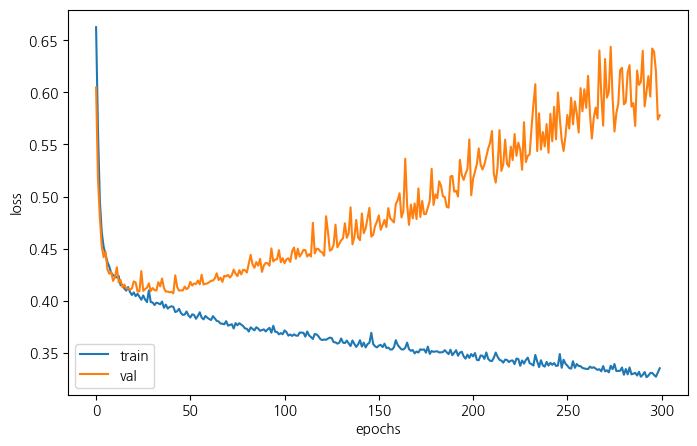

In [49]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* train.loss는 할수록 낮아짐
* val.loss는 할수록 높아짐. 특정 지점 부분에서부터 우상향함 -> 최고점, 과적합이다
* loss가 제일 낮은 부분을 찾아서 그 모델을 사용해야 함

# 모델의 예측 값 출력

In [50]:
pred = model.predict(X_test_ppd)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


array([[1.99022964e-01],
       [7.26085454e-02],
       [1.11653335e-01],
       [1.11899637e-01],
       [6.86308518e-02],
       [5.43838918e-01],
       [7.81131163e-02],
       [1.00000000e+00],
       [1.27347037e-01],
       [9.99613404e-01],
       [7.78238952e-01],
       [9.98649299e-01],
       [2.26419926e-01],
       [1.93553001e-01],
       [9.98044968e-01],
       [6.74715340e-01],
       [1.11653335e-01],
       [3.78996253e-01],
       [9.75812376e-01],
       [2.05327168e-01],
       [1.21366568e-02],
       [4.45206352e-02],
       [5.45832336e-01],
       [1.11899637e-01],
       [3.33438009e-01],
       [9.51339081e-02],
       [9.99954820e-01],
       [1.37252465e-01],
       [2.44520162e-03],
       [1.57762431e-02],
       [9.20035839e-01],
       [9.82513309e-01],
       [1.11653335e-01],
       [6.87476456e-01],
       [9.98849034e-01],
       [4.83380914e-01],
       [1.11653335e-01],
       [2.31225435e-02],
       [1.11653335e-01],
       [3.46605897e-01],


In [54]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] = result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result

,y_test,pred
625,0,0
566,0,0
459,0,0
804,1,0
338,1,0
...,...,...
184,1,1
607,1,0
624,0,0
103,0,0


# Functional API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러 개 쌓는 형태라 복잡한 모델 생성에 한계가 있음.
* Functional  API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output)등 복잡한 모델을 정의 할 수 있음.
* Input(shape=(독립변수 수))로 입력층 정의
* 이전 층을 다음 층의 입력으로 사용
* model()에 입력과 출력을 정의

In [55]:
from keras.layers import Input, Dense
from keras.models import Model

In [56]:
# # 신경망 모델 정의 kearas 3.0, tensorflow 2.19 기준
# model = Sequential()
# model.add(Input(shape=(X_train_ppd.shape[1],))) # 입력층
# model.add(Dense(64, activation='relu')) # 은닉층
# model.add(Dense(32, activation='relu')) # 은닉층
# model.add(Dense(16, activation='relu')) # 은닉층
# model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

In [57]:
# 입력층
inputs = Input(shape=(X_test_ppd.shape[1],))

# 은닉층
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# 출력층
outputs = Dense(1, activation='sigmoid')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
from sklearn.metrics import classification_report

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6035 - loss: 0.6539 - val_accuracy: 0.6306 - val_loss: 0.5983
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7528 - loss: 0.5555 - val_accuracy: 0.8172 - val_loss: 0.5199
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8090 - loss: 0.4957 - val_accuracy: 0.8060 - val_loss: 0.4772
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7994 - loss: 0.4725 - val_accuracy: 0.8060 - val_loss: 0.4617
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7978 - loss: 0.4614 - val_accuracy: 0.8172 - val_loss: 0.4516
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8122 - loss: 0.4509 - val_accuracy: 0.8172 - val_loss: 0.4493
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8106 - loss: 0.4410 - val_accuracy: 0.7873 - val_loss: 0.4536
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8122 - loss: 0.4410 - val_accuracy: 0.8

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8379 - loss: 0.3973 - val_accuracy: 0.7799 - val_loss: 0.4298
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8315 - loss: 0.3962 - val_accuracy: 0.7799 - val_loss: 0.4346
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8299 - loss: 0.3959 - val_accuracy: 0.7873 - val_loss: 0.4287
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8347 - loss: 0.3955 - val_accuracy: 0.7910 - val_loss: 0.4249
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8411 - loss: 0.3942 - val_accuracy: 0.8209 - val_loss: 0.4246
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8363 - loss: 0.3922 - val_accuracy: 0.7761 - val_loss: 0.4301
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8331 - loss: 0.3917 - val_accuracy: 0.7873 - val_loss: 0.4330
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8315 - loss: 0.3975 - val_accuracy: 0.8060 - val

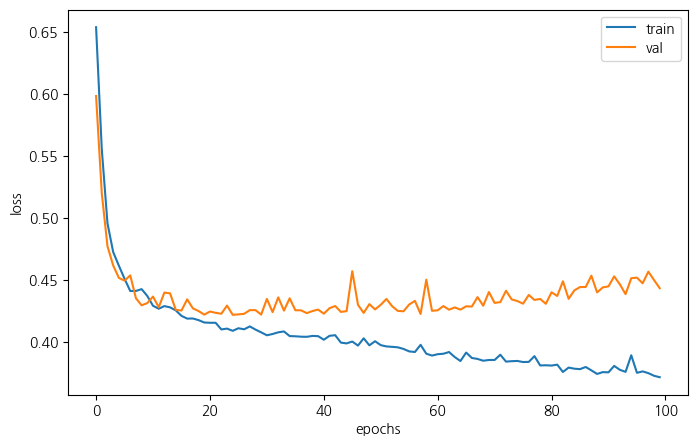

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       165
           1       0.80      0.63      0.71       103

    accuracy                           0.80       268
   macro avg       0.80      0.77      0.78       268
weighted avg       0.80      0.80      0.79       268



In [59]:
# 모델의 파라미터 세팅 # 위에서 가져온 거
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16, 
                    validation_data=(X_test_ppd, y_test))

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] = result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result
print(classification_report(result['y_test'], result['pred']))

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [60]:
class Titanic(Model):
    def __init__(self):
        super().__init__() # 입력층
        self.dense1 = Dense(128, activation='relu') # 은닉층
        self.dense2 = Dense(64, activation='relu') # 은닉층
        self.dense3 = Dense(32, activation='relu') # 은닉층
        self.dense4 = Dense(16, activation='relu') # 은닉층
        self.classifier = Dense(1, activation='sigmoid') # 출력층
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.classifier(x)

In [61]:
model = Titanic() # 클래스는 인스턴스가 있어어 생성됨
print(model.summary())

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7127 - loss: 0.6130 - val_accuracy: 0.7836 - val_loss: 0.5371
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7913 - loss: 0.4939 - val_accuracy: 0.8172 - val_loss: 0.4728
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7929 - loss: 0.4619 - val_accuracy: 0.8134 - val_loss: 0.4494
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8042 - loss: 0.4509 - val_accuracy: 0.8172 - val_loss: 0.4395
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8170 - loss: 0.4394 - val_accuracy: 0.8172 - val_loss: 0.4465
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8090 - loss: 0.4349 - val_accuracy: 0.8209 - val_loss: 0.4345
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8218 - loss: 0.4323 - val_accuracy: 0.8172 - val_loss: 0.4288
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8250 - loss: 0.4264 - val_accuracy: 0.7761 

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8395 - loss: 0.3807 - val_accuracy: 0.8172 - val_loss: 0.4227
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8411 - loss: 0.3801 - val_accuracy: 0.8246 - val_loss: 0.4248
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8443 - loss: 0.3778 - val_accuracy: 0.8022 - val_loss: 0.4279
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8443 - loss: 0.3801 - val_accuracy: 0.8246 - val_loss: 0.4255
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8411 - loss: 0.3785 - val_accuracy: 0.8209 - val_loss: 0.4239
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8331 - loss: 0.3797 - val_accuracy: 0.8246 - val_loss: 0.4255
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8363 - loss: 0.3818 - val_accuracy: 0.8246 - val_loss: 0.4276
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8379 - loss: 0.3821 - val_accuracy: 0.7873 - val_

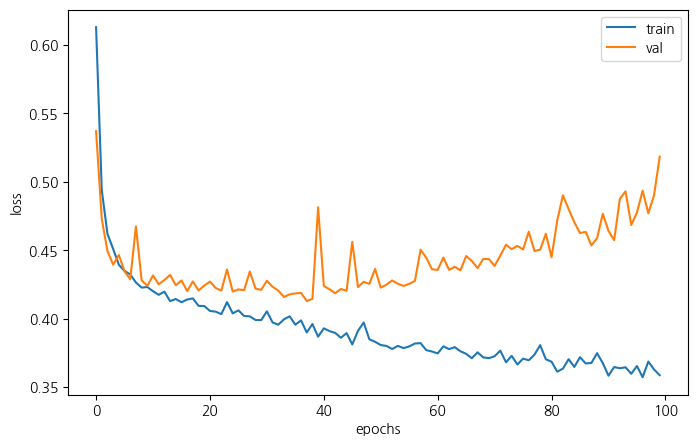

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       165
           1       0.80      0.63      0.71       103

    accuracy                           0.80       268
   macro avg       0.80      0.77      0.78       268
weighted avg       0.80      0.80      0.79       268



In [62]:
# 모델의 파라미터 세팅 # 위에서 가져온 거
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16, 
                    validation_data=(X_test_ppd, y_test))

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] = result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
print(classification_report(result['y_test'], result['pred']))